<a href="https://colab.research.google.com/github/gargi0404/IntroductionToMachineLearning/blob/main/LAB2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

x = torch.rand(5, 3)*2 - 1
x_relu_max = torch.max(torch.zeros_like(x),x)

print("x: {}".format(x))
print("x after ReLU with max: {}".format(x_relu_max))

x: tensor([[ 0.0938,  0.5602,  0.2504],
        [ 0.6035, -0.9662, -0.6536],
        [ 0.4528,  0.2170,  0.5686],
        [-0.0915, -0.9036, -0.3659],
        [ 0.5504, -0.1257,  0.7446]])
x after ReLU with max: tensor([[0.0938, 0.5602, 0.2504],
        [0.6035, 0.0000, 0.0000],
        [0.4528, 0.2170, 0.5686],
        [0.0000, 0.0000, 0.0000],
        [0.5504, 0.0000, 0.7446]])


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.52MB/s]


Train: 60,000 samples | Test: 10,000 samples

APPROACH 1 — Low-level PyTorch (manual nn.Parameter)
Parameters: W1[784, 500]  b1[500]  W2[500, 10]  b2[10]  → total 397,510
  Epoch  1/10  loss=0.7461  train=83.2%  test=89.7%
  Epoch  2/10  loss=0.3545  train=90.2%  test=91.4%
  Epoch  3/10  loss=0.3017  train=91.5%  test=92.3%
  Epoch  4/10  loss=0.2708  train=92.3%  test=92.8%
  Epoch  5/10  loss=0.2473  train=93.0%  test=93.5%
  Epoch  6/10  loss=0.2280  train=93.6%  test=93.8%
  Epoch  7/10  loss=0.2119  train=94.1%  test=94.1%
  Epoch  8/10  loss=0.1978  train=94.4%  test=94.5%
  Epoch  9/10  loss=0.1856  train=94.8%  test=94.8%
  Epoch 10/10  loss=0.1748  train=95.1%  test=95.1%

Low-level  → Final test acc: 95.12%  (187.3s)

APPROACH 2 — High-level nn.Module (OOP)
MLP(
  (fc1): Linear(in_features=784, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)
Parameters: 397,510
  Epoch  1/10  loss=0.7550  train=82.4%  test=89.9%
  Epoch  2/10  loss

/tmp/ipykernel_8670/3839376944.py:208: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(facecolor="#2a2d3a", labelcolor="white", framealpha=0.8)



Plot saved as mnist_mlp_results.png

SUMMARY
Architecture : 784 → FC(500) → ReLU → FC(10)
  Layer 1: 784×500 + 500  = 392,500 params
  Layer 2: 500×10 + 10   = 5,010 params
  Total: 397,510 parameters

Low-level  : 95.12% test acc  (187.3s)
High-level : 95.23% test acc  (187.6s)

Both approaches should give nearly identical results ✓


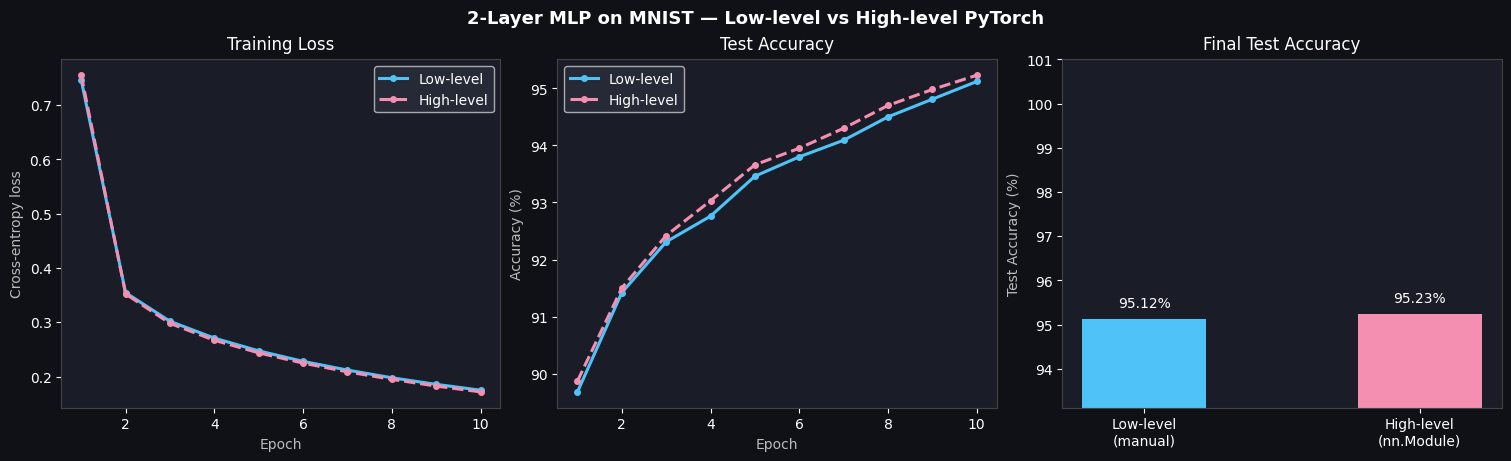

In [2]:
"""
2-Layer MLP for MNIST Digit Classification
===========================================
Assignment: Build a 2-layer MLP two ways:
  1. Low-level PyTorch (manual nn.Parameter + matrix ops)
  2. High-level nn.Module API

Architecture: 784 → FC(500) → ReLU → FC(10) → [CrossEntropyLoss applies softmax]

⚠️  IMPORTANT NOTE on CrossEntropyLoss:
    torch.nn.CrossEntropyLoss() already applies log-softmax internally.
    Always pass RAW LOGITS (pre-softmax outputs) to it.
    Passing softmax outputs into CrossEntropyLoss WILL degrade performance!

Expected performance on real MNIST (~10 epochs, lr=0.01):
    Low-level  : ~97–98% test accuracy
    High-level  : ~97–98% test accuracy
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# ─── Seed for reproducibility ───────────────────────────────────────────────
torch.manual_seed(42)

# ─── Hyperparameters ────────────────────────────────────────────────────────
BATCH_SIZE    = 128
LEARNING_RATE = 0.01
EPOCHS        = 10
INPUT_DIM     = 784   # 28 × 28 pixels flattened
HIDDEN_DIM    = 500
OUTPUT_DIM    = 10    # digits 0–9

# ─── MNIST Data ─────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean / std
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_data):,} samples | Test: {len(test_data):,} samples")

# ═══════════════════════════════════════════════════════════════════════════════
# APPROACH 1  ─  Low-level PyTorch (manual parameters)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("APPROACH 1 — Low-level PyTorch (manual nn.Parameter)")
print("="*60)

# ── Initialise weights with Xavier-uniform and biases at zero ───────────────
W1 = nn.Parameter(torch.empty(INPUT_DIM,  HIDDEN_DIM).uniform_(
        -1 / INPUT_DIM**0.5,  1 / INPUT_DIM**0.5))
b1 = nn.Parameter(torch.zeros(HIDDEN_DIM))

W2 = nn.Parameter(torch.empty(HIDDEN_DIM, OUTPUT_DIM).uniform_(
        -1 / HIDDEN_DIM**0.5, 1 / HIDDEN_DIM**0.5))
b2 = nn.Parameter(torch.zeros(OUTPUT_DIM))

n_params = W1.numel() + b1.numel() + W2.numel() + b2.numel()
print(f"Parameters: W1{list(W1.shape)}  b1{list(b1.shape)}  "
      f"W2{list(W2.shape)}  b2{list(b2.shape)}  → total {n_params:,}")

# ── Pass ALL parameters to a SINGLE optimizer ───────────────────────────────
optimizer_ll = torch.optim.SGD([W1, b1, W2, b2], lr=LEARNING_RATE)
criterion    = nn.CrossEntropyLoss()   # expects logits — no pre-softmax!


def forward_ll(x: torch.Tensor) -> torch.Tensor:
    """Manual forward pass: flatten → hidden(ReLU) → logits."""
    x   = x.view(-1, INPUT_DIM)            # (N, 784)
    h   = torch.relu(x @ W1 + b1)          # (N, 500)
    out = h @ W2 + b2                       # (N, 10)  — raw logits
    return out                              # ← NO softmax here


def run_epoch_ll(loader, train: bool):
    total_loss, correct = 0.0, 0
    for xb, yb in loader:
        logits = forward_ll(xb)
        loss   = criterion(logits, yb)      # CELoss(logits, targets)

        if train:
            optimizer_ll.zero_grad()
            loss.backward()
            optimizer_ll.step()

        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n


history_ll = {"train_loss": [], "train_acc": [], "test_acc": []}
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_ll(train_loader, train=True)
    with torch.no_grad():
        _, te_acc = run_epoch_ll(test_loader, train=False)
    history_ll["train_loss"].append(tr_loss)
    history_ll["train_acc"].append(tr_acc * 100)
    history_ll["test_acc"].append(te_acc * 100)
    print(f"  Epoch {ep:2d}/{EPOCHS}  "
          f"loss={tr_loss:.4f}  train={tr_acc*100:.1f}%  test={te_acc*100:.1f}%")

time_ll = time.time() - t0
print(f"\nLow-level  → Final test acc: {history_ll['test_acc'][-1]:.2f}%  "
      f"({time_ll:.1f}s)")


# ═══════════════════════════════════════════════════════════════════════════════
# APPROACH 2  ─  High-level nn.Module API
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("APPROACH 2 — High-level nn.Module (OOP)")
print("="*60)


class MLP(nn.Module):
    """2-layer MLP: 784 → 500 (ReLU) → 10 (logits)."""

    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(in_dim,    hidden_dim)  # 784 → 500
        self.fc2 = nn.Linear(hidden_dim, out_dim)    # 500 → 10

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(-1, INPUT_DIM)          # flatten
        x = F.relu(self.fc1(x))            # hidden layer + ReLU
        x = self.fc2(x)                    # output logits (NO softmax)
        return x                           # CrossEntropyLoss handles softmax


model = MLP(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# model.parameters() automatically collects ALL trainable params
optimizer_hl = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)


def run_epoch_hl(loader, train: bool):
    model.train(train)
    total_loss, correct = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            logits = model(xb)
            loss   = criterion(logits, yb)   # CELoss(logits, targets)

            if train:
                optimizer_hl.zero_grad()
                loss.backward()
                optimizer_hl.step()

            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(1) == yb).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n


history_hl = {"train_loss": [], "train_acc": [], "test_acc": []}
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_hl(train_loader, train=True)
    _,       te_acc = run_epoch_hl(test_loader,  train=False)
    history_hl["train_loss"].append(tr_loss)
    history_hl["train_acc"].append(tr_acc * 100)
    history_hl["test_acc"].append(te_acc * 100)
    print(f"  Epoch {ep:2d}/{EPOCHS}  "
          f"loss={tr_loss:.4f}  train={tr_acc*100:.1f}%  test={te_acc*100:.1f}%")

time_hl = time.time() - t0
print(f"\nHigh-level → Final test acc: {history_hl['test_acc'][-1]:.2f}%  "
      f"({time_hl:.1f}s)")


# ═══════════════════════════════════════════════════════════════════════════════
# Visualisation
# ═══════════════════════════════════════════════════════════════════════════════
ep_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5),
                         facecolor="#0f1117", constrained_layout=True)
fig.suptitle("2-Layer MLP on MNIST — Low-level vs High-level PyTorch",
             color="white", fontsize=13, fontweight="bold")

colors = {"ll": "#4fc3f7", "hl": "#f48fb1"}

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor("#1a1d27")
    ax.set_title(title, color="white", pad=7)
    ax.set_xlabel(xlabel, color="#bbb")
    ax.set_ylabel(ylabel, color="#bbb")
    ax.tick_params(colors="white")
    ax.legend(facecolor="#2a2d3a", labelcolor="white", framealpha=0.8)
    for s in ax.spines.values():
        s.set_edgecolor("#444")

kw = dict(linewidth=2.2, marker="o", markersize=4)

# ── Training loss ────────────────────────────────────────────────────────────
axes[0].plot(ep_x, history_ll["train_loss"], color=colors["ll"],
             label="Low-level",  **kw)
axes[0].plot(ep_x, history_hl["train_loss"], color=colors["hl"],
             label="High-level", linestyle="--", **kw)
style_ax(axes[0], "Training Loss", "Epoch", "Cross-entropy loss")

# ── Test accuracy ────────────────────────────────────────────────────────────
axes[1].plot(ep_x, history_ll["test_acc"], color=colors["ll"],
             label="Low-level",  **kw)
axes[1].plot(ep_x, history_hl["test_acc"], color=colors["hl"],
             label="High-level", linestyle="--", **kw)
style_ax(axes[1], "Test Accuracy", "Epoch", "Accuracy (%)")

# ── Final accuracy + training time bar ──────────────────────────────────────
ax3 = axes[2]
labels = ["Low-level\n(manual)", "High-level\n(nn.Module)"]
accs   = [history_ll["test_acc"][-1], history_hl["test_acc"][-1]]
bars   = ax3.bar(labels, accs, color=[colors["ll"], colors["hl"]], width=0.45)
for bar, acc in zip(bars, accs):
    ax3.text(bar.get_x() + bar.get_width() / 2, acc + 0.2,
             f"{acc:.2f}%", ha="center", va="bottom", color="white", fontsize=10)
ax3.set_ylim(min(accs) - 2, 101)
ax3.set_ylabel("Test Accuracy (%)", color="#bbb")
style_ax(ax3, "Final Test Accuracy", "", "Test Accuracy (%)")
# Remove unused legend from bar chart
ax3.get_legend().remove()

fig.savefig("mnist_mlp_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\nPlot saved as mnist_mlp_results.png")


# ─── Final summary ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Architecture : {INPUT_DIM} → FC({HIDDEN_DIM}) → ReLU → FC({OUTPUT_DIM})")
print(f"  Layer 1: {INPUT_DIM}×{HIDDEN_DIM} + {HIDDEN_DIM}  = {INPUT_DIM*HIDDEN_DIM+HIDDEN_DIM:,} params")
print(f"  Layer 2: {HIDDEN_DIM}×{OUTPUT_DIM} + {OUTPUT_DIM}   = {HIDDEN_DIM*OUTPUT_DIM+OUTPUT_DIM:,} params")
print(f"  Total: {n_params:,} parameters")
print(f"\nLow-level  : {history_ll['test_acc'][-1]:.2f}% test acc  ({time_ll:.1f}s)")
print(f"High-level : {history_hl['test_acc'][-1]:.2f}% test acc  ({time_hl:.1f}s)")
print(f"\nBoth approaches should give nearly identical results ✓")
